# Adversarial Threats to Cloud IDS — PyTorch Reimplementation (Local / RX7600 ROCm)

Reimplements the methodology from *"Adversarial Threats to Cloud IDS: Robust Defense With
Adversarial Training and Feature Selection"* (Holla, Polepalli & Sasikumar, IEEE Access 2025)
on the `dhoogla/csecicids2018` (CSE-CIC-IDS2018) cleaned Parquet dataset, using **PyTorch**
instead of TensorFlow.

**This variant:** reads Parquet (or CSV fallback) files from a local `data/` folder and trains
on your AMD RX7600 8GB GPU via **ROCm** (`HSA_OVERRIDE_GFX_VERSION=11.0.0`), not DirectML.
Measured ~4.2x faster per-epoch than the DirectML backend on this same architecture.

**GPU/CPU split (important):**
- Model **training and plain inference** run on ROCm (your RX7600, exposed as `cuda`) — this is
  where most wall-clock time goes, so it's accelerated.
- **ART (Adversarial Robustness Toolbox) attack generation — FGSM, PGD, DeepFool — always runs
  on CPU.** This is a deliberate, unchanged design choice (not a ROCm limitation) — ART's
  gradient interop is most reliably tested against a plain CPU model, so each attack step copies
  the model's weights to a CPU-resident copy and attacks that instead.
- The custom **tabular Square Attack** (black-box, gradient-free) and **SHAP** analysis are pure
  forward passes, so those *do* use the GPU for speed.

**Known caveat — backend sensitivity:** an earlier ROCm run of this same architecture/config
(with the identical data pipeline verified byte-for-byte against a DirectML reference run)
produced baseline clean accuracy ~10 points higher (~95-97%) than the DirectML run (~86%, which
closely matched the paper's 85%). Since the data-loading/cleaning/feature-selection code was
confirmed identical between the two runs, this gap is most likely attributable to genuine
numerical/training-dynamics differences between the two GPU backends (weight-init RNG
consumption order, BatchNorm/kernel implementation differences), not a data or logic bug. **This
should be treated as an open finding to verify and report, not something silently resolved by
this patch** — re-run and compare against your DirectML reference numbers before trusting the
absolute accuracy figures from this backend.

**Fixes carried over / added:**
- **`DATA_SEED` vs `SEED` split** — train/test split, SMOTE, and feature selection all use the
  fixed `DATA_SEED`; only model weight initialization and training stochasticity vary with
  `SEED`. This isolates "does the training recipe converge reliably across different inits" from
  "are we accidentally comparing different datasets," which earlier single-seed runs conflated.
- **Ground-truth-targeted attacks** — FGSM/PGD/DeepFool all pass `y=to_onehot(y_true)` rather
  than relying on ART's default (which targets the model's *own* prediction and silently
  inverts robustness numbers for models with imperfect clean accuracy).
- **DeepFool eps-capping** — ART's DeepFool has no perturbation budget; capped to the same
  L_inf ball as FGSM/PGD for a fair comparison (see `cap_to_eps` docstring).
- **Equal baseline/Stage-1 training budget** — both train for `CONFIG['epochs_baseline']`
  epochs, so overhead isolates Stage 2's cost, not a shorter training run.
- **Attack success rate + perturbation magnitude logging** — every attack now reports actual
  mean L_inf/L2 perturbation and a proper success-rate definition (fraction of *originally
  correct* predictions flipped), not the `1 - accuracy` proxy used in earlier versions, which
  conflates attack effectiveness with pre-existing model errors.
- Table 4 (accuracy under attack) reports all four paper metrics — Accuracy, F1, Precision,
  Recall — plus the corrected success rate.
- Nearly every hyperparameter (architecture width/depth, dropout, learning rate, val/test
  splits, attack budgets, sample sizes, SHAP background size, Square Attack step schedule) is
  now in `CONFIG`, not hardcoded — see Section 2.

**Folders:** dataset must be placed in `./data/` (Parquet or CSV, any/all of the 10 daily
CSE-CIC-IDS2018 files). Outputs (tables, plots, models, metrics) are saved under
`./output/seed_{SEED}/`, so multiple seed runs never overwrite each other.


## Section 1 — Install packages

In [1]:
# rocm_env already has torch+ROCm installed separately (torch==2.9.1+rocm7.2.1 or similar) -
# only install the remaining pipeline dependencies here.
!pip install -q adversarial-robustness-toolbox shap imbalanced-learn tqdm pandas scikit-learn matplotlib



[notice] A new release of pip is available: 26.0.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Section 2 — Imports, structured logger, and config
onehot function
Every cell below prints timestamped progress lines / progress bars — there is no cell that runs silently with a blank wait.

In [2]:
import os
os.environ["HSA_OVERRIDE_GFX_VERSION"] = "11.0.0"  # must precede `import torch` - do not move this

import glob, time, json, pickle, shutil, warnings
from datetime import datetime

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, VarianceThreshold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import shap
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent, DeepFool
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# --- Seed handling -----------------------------------------------------
# DATA_SEED is FIXED across every seed-stability run: it controls train/test
# split, SMOTE, and feature selection. If this varied per "seed run," you'd
# silently be comparing different datasets instead of different model inits.
# SEED VARIES per run: it controls only model weight init + training order.
# Both are overridable via env vars so external driver scripts can chain
# multiple seeds without editing this notebook (RUN_SEED / RUN_DATA_SEED).
DATA_SEED = int(os.environ.get("RUN_DATA_SEED", 42))
SEED = int(os.environ.get("RUN_SEED", 42))
np.random.seed(SEED)
torch.manual_seed(SEED)


class Logger:
    """Structured logger: every step prints a timestamped, labeled line. No silent/blank cells."""
    def __init__(self):
        self.t0 = time.time()
        self.section_num = 0

    def _elapsed(self):
        s = time.time() - self.t0
        m, s = divmod(s, 60)
        h, m = divmod(m, 60)
        return f"{int(h):02d}:{int(m):02d}:{s:05.2f}"

    def section(self, title):
        self.section_num += 1
        bar = "=" * 78
        print(f"\n{bar}")
        print(f">>> [{self._elapsed()}] SECTION {self.section_num}: {title}")
        print(bar)

    def info(self, msg):
        print(f"    . [{self._elapsed()}] {msg}")

    def ok(self, msg):
        print(f"    v [{self._elapsed()}] {msg}")

    def warn(self, msg):
        print(f"    ! [{self._elapsed()}] WARNING: {msg}")

    def metric(self, label, value):
        print(f"    > [{self._elapsed()}] {label:<42s} {value}")


log = Logger()
print(f"Run started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')} | SEED={SEED} | DATA_SEED={DATA_SEED}")

# Folder-per-seed: every run gets its own output directory, so chained
# multi-seed runs never overwrite each other.
OUTPUT_DIR = f"./output/seed_{SEED}"
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(f"{OUTPUT_DIR}/checkpoints", exist_ok=True)

CONFIG = {
    # --- Data ---
    "day_patterns": None,           # None = load all files found in data/ (all 10 days)
    "max_rows_per_file": None,      # set e.g. 500_000 if you hit RAM/SMOTE slowness
    "test_size": 0.2,               # train/test split fraction

    # --- Feature selection (paper Tables 2-3; T unspecified in the paper) ---
    "top_t_mutual_info": 25,        # features kept after MI ranking
    "top_t_shap": 15,               # features kept after SHAP stability ranking
    "mi_var_thresh": 1e-5,          # VarianceThreshold cutoff before MI ranking
    "mi_sample_size": 50000,        # row subsample used for MI computation (speed)
    "shap_background_samples": 100, # background set size for shap.Explainer

    "structural_features": ["proto_TCP", "proto_UDP", "proto_ICMP"],  # adjust names to match your actual proto_* one-hot columns after get_dummies

    # --- Model architecture (paper states "3 hidden layers, BatchNorm, Dropout,
    #     Adam lr=0.001" but never gives widths - 128/64/32 is our assumption) ---
    "hidden_sizes": [128, 64, 32],
    "dropout": 0.3,
    "learning_rate": 0.001,
    "val_split": 0.1,               # held-out fraction of training data for val_acc tracking

    # --- Attacks (paper doesn't state eps/iteration counts) ---
    "attack_eps": 0.05,             # L_inf budget on standardized features
    "pgd_iters": 20,
    "pgd_eps_step_ratio": 0.1,      # PGD per-step size = attack_eps * this ratio
    "deepfool_iters": 50,
    "square_iters": 300,
    "square_p_init": 0.3,           # Square Attack's initial perturbed-feature fraction

    # --- Evaluation sample sizes ---
    "n_attack_eval_samples": 2000,  # test-set subsample used to evaluate FGSM/PGD/DeepFool
    "n_square_samples": 1000,
    "n_shap_samples": 300,
    "n_adv_train_samples": 5000,    # clean samples per attack type used to build adv. training data

    # --- Training schedule ---
    "epochs_baseline": 50,
    "epochs_defended_stage1": 50,   # matches epochs_baseline so overhead isolates Stage 2's cost
    "epochs_defended_stage2": 15,   # this is the real "added" cost the paper's ~25% overhead reports
    "batch_size": 512,

    # --- Seeds (recorded for the run_config.json snapshot) ---
    "seed": SEED,
    "data_seed": DATA_SEED,
}
log.info(f"CONFIG = {json.dumps(CONFIG, indent=2)}")
log.info(f"Outputs will be saved to: {OUTPUT_DIR}")


def to_onehot(y, n_classes=2):
    """ART's PyTorchClassifier expects one-hot y for generate() ground-truth targeting."""
    return np.eye(n_classes, dtype=np.float32)[y]


F:\PythonProjects\aml_rocm_native\rocm_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Run started: 2026-08-01 19:50:47 | SEED=42 | DATA_SEED=42
    . [00:00:00.00] CONFIG = {
  "day_patterns": null,
  "max_rows_per_file": null,
  "test_size": 0.2,
  "top_t_mutual_info": 25,
  "top_t_shap": 15,
  "mi_var_thresh": 1e-05,
  "mi_sample_size": 50000,
  "shap_background_samples": 100,
  "structural_features": [
    "proto_TCP",
    "proto_UDP",
    "proto_ICMP"
  ],
  "hidden_sizes": [
    128,
    64,
    32
  ],
  "dropout": 0.3,
  "learning_rate": 0.001,
  "val_split": 0.1,
  "attack_eps": 0.05,
  "pgd_iters": 20,
  "pgd_eps_step_ratio": 0.1,
  "deepfool_iters": 50,
  "square_iters": 300,
  "square_p_init": 0.3,
  "n_attack_eval_samples": 2000,
  "n_square_samples": 1000,
  "n_shap_samples": 300,
  "n_adv_train_samples": 5000,
  "epochs_baseline": 50,
  "epochs_defended_stage1": 50,
  "epochs_defended_stage2": 15,
  "batch_size": 512,
  "seed": 42,
  "data_seed": 42
}
    . [00:00:00.00] Outputs will be saved to: ./output/seed_42


## Section 3 — Device setup (ROCm)


In [3]:
log.section("Device setup (ROCm)")

CPU_DEVICE = torch.device("cpu")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    log.ok(f"ROCm device acquired: {DEVICE} ({torch.cuda.get_device_name(0)})")
else:
    log.warn("ROCm/CUDA not available. Falling back to CPU. "
             "Check HSA_OVERRIDE_GFX_VERSION was set before `import torch` (Cell 4), "
             "and that this kernel is using your rocm_env interpreter.")
    DEVICE = CPU_DEVICE

log.info(f"Torch version: {torch.__version__}")
log.info(f"Training/inference device : {DEVICE}")
log.info(f"ART attack device (fixed) : {CPU_DEVICE}  (attacks always run on CPU, see intro cell)")



>>> [00:00:00.06] SECTION 1: Device setup (ROCm)
    v [00:00:00.08] ROCm device acquired: cuda (AMD Radeon RX 7600)
    . [00:00:00.08] Torch version: 2.9.1+rocm7.2.1
    . [00:00:00.08] Training/inference device : cuda
    . [00:00:00.08] ART attack device (fixed) : cpu  (attacks always run on CPU, see intro cell)


## Section 4 — Load the dataset

In [4]:
log.section("Loading dataset from local data/ folder")

DATA_DIR = "data"
if not os.path.isdir(DATA_DIR):
    raise FileNotFoundError(
        f"'{DATA_DIR}/' not found next to this notebook. "
        "Download the CSE-CIC-IDS2018 parquet files (Kaggle dataset "
        "'dhoogla/csecicids2018') and place them in a 'data' folder "
        "next to this notebook, then re-run this cell."
    )

all_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.parquet"), recursive=True))
if not all_files:
    # fallback in case someone drops raw CSVs in the same folder
    all_files = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.csv"), recursive=True))
if not all_files:
    raise FileNotFoundError(f"No .parquet or .csv files found under '{DATA_DIR}/'. Place the dataset files there.")

log.ok(f"Found {len(all_files)} data file(s) in '{DATA_DIR}/':")
for p in all_files:
    size_mb = os.path.getsize(p) / (1024 * 1024)
    print(f"        - {os.path.basename(p)}  ({size_mb:,.1f} MB)")


>>> [00:00:00.12] SECTION 2: Loading dataset from local data/ folder
    v [00:00:00.12] Found 10 data file(s) in 'data/':
        - Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet  (79.6 MB)
        - Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet  (72.9 MB)
        - DDoS1-Tuesday-20-02-2018_TrafficForML_CICFlowMeter.parquet  (85.3 MB)
        - DDoS2-Wednesday-21-02-2018_TrafficForML_CICFlowMeter.parquet  (31.9 MB)
        - DoS1-Thursday-15-02-2018_TrafficForML_CICFlowMeter.parquet  (94.0 MB)
        - DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet  (55.3 MB)
        - Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet  (48.6 MB)
        - Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet  (27.9 MB)
        - Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet  (99.1 MB)
        - Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet  (96.7 MB)


## Section 5 — Load selected daily files

In [5]:
log.section("Loading selected daily files")
DAY_PATTERNS = CONFIG["day_patterns"]

if DAY_PATTERNS is None:
    selected_files = all_files
else:
    selected_files = [p for p in all_files if any(pat in os.path.basename(p) for pat in DAY_PATTERNS)]
    for pat in DAY_PATTERNS:
        if not any(pat in os.path.basename(p) for p in all_files):
            log.warn(f"No file matching '{pat}' - check filenames above and adjust CONFIG['day_patterns'].")

if not selected_files:
    log.warn("No file matched day_patterns - falling back to ALL found files.")
    selected_files = all_files

MAX_ROWS_PER_FILE = CONFIG.get("max_rows_per_file")  # None = no cap, load everything

dfs = []
for p in tqdm(selected_files, desc="Loading data files"):
    if p.endswith(".parquet"):
        d = pd.read_parquet(p, engine="pyarrow")
    else:
        d = pd.read_csv(p, low_memory=False)

    # Downcast to float32 immediately - halves RAM footprint vs. float64,
    # which matters once you're loading all 10 days instead of 3.
    float_cols = d.select_dtypes(include=["float64"]).columns
    d[float_cols] = d[float_cols].astype(np.float32)

    if MAX_ROWS_PER_FILE is not None and len(d) > MAX_ROWS_PER_FILE:
        # FIX: DATA_SEED, not SEED - this subsampling changes the actual
        # dataset contents, so it belongs with the other data-level seeds.
        d = d.sample(n=MAX_ROWS_PER_FILE, random_state=DATA_SEED)
        log.info(f"{os.path.basename(p)}: subsampled to {MAX_ROWS_PER_FILE:,} rows")

    log.info(f"{os.path.basename(p)}: {d.shape[0]:,} rows x {d.shape[1]} cols")
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)
del dfs
log.ok(f"Combined raw shape: {df.shape[0]:,} rows x {df.shape[1]} cols")
df.head()



>>> [00:00:00.15] SECTION 3: Loading selected daily files


Loading data files:   0%|          | 0/10 [00:00<?, ?it/s]

    . [00:00:00.30] Botnet-Friday-02-03-2018_TrafficForML_CICFlowMeter.parquet: 771,587 rows x 78 cols

Loading data files:  10%|█         | 1/10 [00:00<00:01,  6.72it/s]


    . [00:00:00.40] Bruteforce-Wednesday-14-02-2018_TrafficForML_CICFlowMeter.parquet: 619,346 rows x 78 cols


...

    . [00:00:00.77] DoS2-Friday-16-02-2018_TrafficForML_CICFlowMeter.parquet: 591,873 rows x 78 cols
    . [00:00:00.84] Infil1-Wednesday-28-02-2018_TrafficForML_CICFlowMeter.parquet: 456,873 rows x 78 cols
    . [00:00:00.89] Infil2-Thursday-01-03-2018_TrafficForML_CICFlowMeter.parquet: 249,170 rows x 78 cols


Loading data files: 100%|██████████| 10/10 [00:00<00:00, 10.19it/s]

    . [00:00:01.02] Web1-Thursday-22-02-2018_TrafficForML_CICFlowMeter.parquet: 830,224 rows x 78 cols
    . [00:00:01.14] Web2-Friday-23-02-2018_TrafficForML_CICFlowMeter.parquet: 829,405 rows x 78 cols


    v [00:00:02.34] Combined raw shape: 6,659,532 rows x 78 cols


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,141385,9,7,553,3773.0,202,0,61.444443,87.534439,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,6,281,2,1,38,0.0,38,0,19.000000,26.870058,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,6,279824,11,15,1086,10527.0,385,0,98.727272,129.392502,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,6,132,2,0,0,0.0,0,0,0.000000,0.000000,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,6,274016,9,13,1285,6141.0,517,0,142.777771,183.887726,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


## Section 6 — Data cleaning

Handles four real quirks of this dataset that will otherwise throw errors or silently corrupt features:
- **Column name whitespace** (`' Label'`, `'Dst Port '`, etc.)
- **Duplicate column names** across concatenated files
- **Repeated header rows embedded mid-file** — literal rows containing the string `"Label"` as data
- **`'Infinity'` / `'-Infinity'` / blank string values** in rate columns (`Flow Byts/s`, `Flow Pkts/s`) when flow duration is zero

In [6]:
log.section("Data cleaning")

df.columns = df.columns.str.strip()
log.info("Stripped whitespace from column names")

n_cols_before = df.shape[1]
df = df.loc[:, ~df.columns.duplicated()]
if df.shape[1] != n_cols_before:
    log.warn(f"Dropped {n_cols_before - df.shape[1]} duplicate-named column(s)")

# FIX: dhoogla's parquet build may store some columns (notably Label) as
# pandas 'category' dtype rather than 'object'. Cast category -> object
# up front so every downstream dtype check (label lookup, to_numeric loop
# in Section 7) behaves identically regardless of source format (raw CSV
# vs. cleaned parquet).
cat_cols = df.select_dtypes(include="category").columns
if len(cat_cols) > 0:
    df[cat_cols] = df[cat_cols].astype(object)
    log.info(f"Cast {len(cat_cols)} category column(s) to object: {list(cat_cols)}")

label_col = next((c for c in df.columns if c.strip().lower() == "label"), None)
if label_col is None:
    raise KeyError(f"No 'Label' column found. Available columns: {list(df.columns)}")
df = df.rename(columns={label_col: "Label"})
log.ok(f"Label column identified: '{label_col}' -> renamed to 'Label'")

before = len(df)
df = df[df["Label"].astype(str).str.strip().str.lower() != "label"]
dropped = before - len(df)
if dropped:
    log.warn(f"Dropped {dropped:,} embedded-header rows (repeated 'Label' as data)")

drop_cols = [c for c in ["Timestamp", "Flow ID", "Src IP", "Dst IP", "Source IP",
                          "Destination IP", "Src IP Addr", "Dst IP Addr"] if c in df.columns]
if drop_cols:
    df = df.drop(columns=drop_cols)
    log.info(f"Dropped identity/temporal columns: {drop_cols}")

before = len(df)
df = df.drop_duplicates()
dropped = before - len(df)
log.ok(f"Dropped {dropped:,} duplicate rows (data cleaning) - {len(df):,} rows remain")


>>> [00:00:02.48] SECTION 4: Data cleaning
    . [00:00:02.48] Stripped whitespace from column names
    v [00:00:02.48] Label column identified: 'Label' -> renamed to 'Label'
    v [00:00:47.25] Dropped 573,667 duplicate rows (data cleaning) - 6,085,865 rows remain


## Section 7 — Binary labeling and categorical encoding

In [7]:
log.section("Binary labeling and encoding")

label_col = next((c for c in df.columns if c.strip().lower() == "label"), "Label")
df["y"] = (df[label_col].astype(str).str.strip().str.lower() != "benign").astype(int)
df = df.drop(columns=[label_col])
log.ok(f"Binary label created: {np.bincount(df['y'])} (0=benign, 1=attack)")

proto_col = next((c for c in df.columns if c.strip().lower() == "protocol"), None)
if proto_col is not None:
    df = pd.get_dummies(df, columns=[proto_col], prefix="proto")
    log.info(f"One-hot encoded '{proto_col}'")

# FIX: check both object AND category dtype (parquet source may use either)
non_numeric_cols = df.select_dtypes(include=["object", "category"]).columns
for c in non_numeric_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
if len(non_numeric_cols) > 0:
    log.info(f"Coerced {len(non_numeric_cols)} non-numeric column(s) to numeric: {list(non_numeric_cols)}")
df = df.dropna()

X = df.drop(columns=["y"]).reset_index(drop=True).astype(np.float32)
y = df["y"].values.astype(np.int64)
log.ok(f"Final feature matrix: {X.shape} | class balance: {np.bincount(y)}")


>>> [00:00:47.57] SECTION 5: Binary labeling and encoding
    v [00:00:47.97] Binary label created: [4760022 1325843] (0=benign, 1=attack)
    . [00:00:48.08] One-hot encoded 'Protocol'
    v [00:00:48.84] Final feature matrix: (6085865, 79) | class balance: [4760022 1325843]


## Section 8 — Robust feature selection: mutual information + variance threshold (paper Table 2)

In [8]:
log.section("Mutual-information feature selection")

def robust_feature_selection(X, y, top_t, var_thresh=None, mi_sample_size=None, seed=DATA_SEED):
    var_thresh = CONFIG["mi_var_thresh"] if var_thresh is None else var_thresh
    mi_sample_size = CONFIG["mi_sample_size"] if mi_sample_size is None else mi_sample_size

    vt = VarianceThreshold(threshold=var_thresh)
    vt.fit(X)
    kept_var = X.columns[vt.get_support()]
    log.info(f"Variance threshold kept {len(kept_var)}/{X.shape[1]} features")
    X_v = X[kept_var]

    rng = np.random.RandomState(seed)
    if len(X_v) > mi_sample_size:
        idx = rng.choice(len(X_v), mi_sample_size, replace=False)
        X_mi, y_mi = X_v.iloc[idx], y[idx]
        log.info(f"Computing mutual information on a {mi_sample_size:,}-row subsample for speed")
    else:
        X_mi, y_mi = X_v, y

    mi = mutual_info_classif(X_mi, y_mi, random_state=seed)
    mi_series = pd.Series(mi, index=X_v.columns).sort_values(ascending=False)
    selected = mi_series.head(top_t).index.tolist()
    return selected, mi_series

selected_features, mi_scores = robust_feature_selection(X, y, top_t=CONFIG["top_t_mutual_info"])
log.ok(f"Selected {len(selected_features)} features by mutual information")
print(selected_features)



>>> [00:00:49.07] SECTION 6: Mutual-information feature selection
    . [00:00:54.82] Variance threshold kept 71/79 features
    . [00:00:55.09] Computing mutual information on a 50,000-row subsample for speed
    v [00:01:07.36] Selected 25 features by mutual information
['Bwd Packets Length Total', 'Avg Bwd Segment Size', 'Subflow Bwd Bytes', 'Bwd Packet Length Mean', 'Fwd Packets Length Total', 'Subflow Fwd Bytes', 'Bwd Packet Length Max', 'Fwd Packet Length Max', 'Avg Fwd Segment Size', 'Fwd Packet Length Mean', 'Bwd Packet Length Std', 'Fwd Packet Length Std', 'Packet Length Variance', 'Packet Length Std', 'Packet Length Mean', 'Packet Length Max', 'Avg Packet Size', 'Fwd Header Length', 'Init Fwd Win Bytes', 'Fwd IAT Max', 'Fwd IAT Total', 'Init Bwd Win Bytes', 'Flow IAT Max', 'Bwd Header Length', 'Fwd IAT Mean']


## Section 9 — Train/test split, scaling, SMOTE balancing

In [9]:
log.section("Split / scale / balance")

X_sel = X[selected_features].values
X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=CONFIG["test_size"], random_state=DATA_SEED, stratify=y
)
log.info(f"Train: {X_train.shape}  Test: {X_test.shape}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)
log.ok("Standardized features (fit on train only)")

sm = SMOTE(random_state=DATA_SEED)
X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
X_train_bal = X_train_bal.astype(np.float32)
log.ok(f"SMOTE-balanced train set: {X_train_bal.shape} | class balance: {np.bincount(y_train_bal)}")



>>> [00:01:07.40] SECTION 7: Split / scale / balance
    . [00:01:11.68] Train: (4868692, 25)  Test: (1217173, 25)
    v [00:01:13.14] Standardized features (fit on train only)
    v [00:16:04.43] SMOTE-balanced train set: (7616036, 25) | class balance: [3808018 3808018]


## Section 10 — PyTorch model architecture and training/eval helpers

**ASSUMPTION carried over from the paper:** it states "three hidden layers, batch normalization,
dropout ... Adam, lr=0.001" but never gives layer widths. We use 128 -> 64 -> 32 units by default,
same as the original reimplementation - now configurable via `CONFIG['hidden_sizes']`,
`CONFIG['dropout']`, and `CONFIG['learning_rate']`.


In [10]:
class IDSNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=None, dropout=None):
        super().__init__()
        hidden_sizes = CONFIG["hidden_sizes"] if hidden_sizes is None else hidden_sizes
        dropout = CONFIG["dropout"] if dropout is None else dropout

        layers = []
        prev = input_dim
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 2))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def train_model(model, X_train, y_train, epochs, batch_size, device, class_weights=None,
                 desc="Training", val_split=None, seed=DATA_SEED, lr=None):
    """Trains an IDSNet on `device`. Returns a history dict (loss/val_loss/val_acc per epoch)."""
    val_split = CONFIG["val_split"] if val_split is None else val_split
    lr = CONFIG["learning_rate"] if lr is None else lr

    model.to(device)
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(X_train))
    n_val = max(1, int(len(X_train) * val_split))
    val_idx, tr_idx = idx[:n_val], idx[n_val:]

    X_tr_t = torch.tensor(X_train[tr_idx], dtype=torch.float32)
    y_tr_t = torch.tensor(y_train[tr_idx], dtype=torch.long)
    train_ds = torch.utils.data.TensorDataset(X_tr_t, y_tr_t)
    train_loader = torch.utils.data.DataLoader(train_ds, batch_size=batch_size, shuffle=True)

    X_val_t = torch.tensor(X_train[val_idx], dtype=torch.float32).to(device)
    y_val_t = torch.tensor(y_train[val_idx], dtype=torch.long).to(device)

    if class_weights is not None:
        cw = torch.tensor(class_weights, dtype=torch.float32).to(device)
        criterion = nn.CrossEntropyLoss(weight=cw)
    else:
        criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"loss": [], "val_loss": [], "val_acc": []}
    pbar = tqdm(range(epochs), desc=desc)
    for _ in pbar:
        model.train()
        epoch_loss, n_batches = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            n_batches += 1
        model.eval()
        with torch.no_grad():
            val_out = model(X_val_t)
            val_loss = criterion(val_out, y_val_t).item()
            val_acc = (val_out.argmax(1) == y_val_t).float().mean().item()
        history["loss"].append(epoch_loss / max(n_batches, 1))
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        pbar.set_postfix(loss=f"{epoch_loss/max(n_batches,1):.4f}", val_acc=f"{val_acc:.4f}")
    return history


def predict_proba_numpy(model, X, device, batch_size=4096):
    """Numpy-in, numpy-out softmax predictions. Used by evaluate(), SHAP, and the tabular Square Attack."""
    model.eval()
    model.to(device)
    outs = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            xb = torch.tensor(np.asarray(X[i:i + batch_size]), dtype=torch.float32).to(device)
            probs = torch.softmax(model(xb), dim=1)
            outs.append(probs.detach().to("cpu").numpy())
    return np.vstack(outs)


def evaluate(model, X, y, device, label=""):
    t0 = time.time()
    probs = predict_proba_numpy(model, X, device)
    infer_ms = (time.time() - t0) / len(X) * 1000
    preds = probs.argmax(axis=1)
    acc = accuracy_score(y, preds)
    f1 = f1_score(y, preds, zero_division=0)
    prec = precision_score(y, preds, zero_division=0)
    rec = recall_score(y, preds, zero_division=0)
    log.metric(label, f"Acc={acc:.3f}  F1={f1:.3f}  Prec={prec:.3f}  Rec={rec:.3f}  Infer={infer_ms:.4f} ms/sample")
    return dict(accuracy=acc, f1=f1, precision=prec, recall=rec, infer_ms=infer_ms)


def attack_diagnostics(model, X_clean, X_adv, y_true, device):
    """Perturbation magnitude + proper attack success rate.

    RECHECK ADDITION: success rate is the fraction of *originally correct*
    predictions that get flipped by the attack - NOT `1 - accuracy`, which
    conflates attack effectiveness with pre-existing model errors and was
    the metric used in earlier versions of this notebook (see Table 5).
    """
    l_inf = np.abs(X_adv - X_clean).max(axis=1)
    l2 = np.linalg.norm(X_adv - X_clean, axis=1)
    clean_preds = predict_proba_numpy(model, X_clean, device).argmax(1)
    adv_preds = predict_proba_numpy(model, X_adv, device).argmax(1)
    was_correct = (clean_preds == y_true)
    n_correct = int(was_correct.sum())
    success_rate = float(((clean_preds != adv_preds) & was_correct).sum() / max(n_correct, 1))
    return dict(mean_linf=float(l_inf.mean()), max_linf=float(l_inf.max()),
                mean_l2=float(l2.mean()), success_rate=success_rate, n_originally_correct=n_correct)


def make_art_classifier(model, input_dim, clip_values):
    """Copies `model`'s weights onto a fresh CPU-resident model and wraps it for ART.
    ART attack generation always happens on CPU by design (see intro cell)."""
    cpu_model = IDSNet(input_dim)
    cpu_model.load_state_dict(model.state_dict())
    cpu_model.to("cpu")
    cpu_model.eval()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(cpu_model.parameters(), lr=CONFIG["learning_rate"])
    clf = PyTorchClassifier(
        model=cpu_model,
        loss=criterion,
        optimizer=optimizer,
        input_shape=(input_dim,),
        nb_classes=2,
        clip_values=clip_values,
        device_type="cpu",
    )
    return clf, cpu_model

def cap_to_eps(X_adv, X_clean, eps, clip_values):
    """Clip an attack's perturbation to the same L_inf eps-ball used by FGSM/PGD.

    BUG FIX: FGSM and PGD both respect `eps` internally (it's a required
    constructor argument), but ART's DeepFool has NO perturbation budget at
    all -- it keeps perturbing each sample until it crosses the decision
    boundary, however far that takes it. Empirically this produces L_inf
    perturbations 60-150x larger than the eps=0.05 budget used for FGSM/PGD
    (measured: mean L_inf ~3.0, max ~7.4, vs. the 0.05 budget), driving
    accuracy under DeepFool to near-zero -- an artifact of an unbounded
    attack, not a meaningful robustness comparison. It also poisons stage-2
    adversarial training with wildly out-of-distribution samples pinned to
    the clip bounds, which is what was dragging the defended model's clean
    accuracy down too.

    This caps DeepFool's output to the same L_inf budget as FGSM/PGD, which
    also matches the paper's own stated assumption that perturbations are
    "subtle" and preserve functional integrity (Section I: "adversarial
    attacks ... introduce subtle feature perturbations that do not alter
    fundamental traffic functionality").
    """
    delta = np.clip(X_adv - X_clean, -eps, eps)
    return np.clip(X_clean + delta, clip_values[0], clip_values[1]).astype(np.float32)


log.ok("Model + train/eval/ART helper functions defined")


    v [00:16:04.48] Model + train/eval/ART helper functions defined


## Section 11 — Train baseline model

In [11]:
log.section("Training baseline model")

input_dim = X_train_bal.shape[1]
baseline_model = IDSNet(input_dim)
log.info(f"Model: input_dim={input_dim}, hidden_sizes={CONFIG['hidden_sizes']}, "
         f"epochs={CONFIG['epochs_baseline']}, device={DEVICE}")

t0 = time.time()
history = train_model(
    baseline_model, X_train_bal, y_train_bal,
    epochs=CONFIG["epochs_baseline"], batch_size=CONFIG["batch_size"],
    device=DEVICE, desc="Baseline training",
)
baseline_train_time = time.time() - t0
log.ok(f"Baseline training complete in {baseline_train_time/60:.2f} min")

torch.save(baseline_model.state_dict(), f"{OUTPUT_DIR}/checkpoints/baseline_seed{CONFIG['seed']}.pt")
log.ok(f"Saved baseline checkpoint for seed {CONFIG['seed']}")



>>> [00:16:04.50] SECTION 8: Training baseline model
    . [00:16:04.51] Model: input_dim=25, hidden_sizes=[128, 64, 32], epochs=50, device=cuda


Baseline training: 100%|██████████| 50/50 [1:06:13<00:00, 79.47s/it, loss=0.1554, val_acc=0.9429]

    v [01:22:20.76] Baseline training complete in 66.27 min
    v [01:22:20.77] Saved baseline checkpoint for seed 42


## Section 12 — Evaluate baseline on clean test data

In [12]:
log.section("Evaluating baseline on clean test data")
baseline_clean_metrics = evaluate(baseline_model, X_test, y_test, DEVICE, "Baseline (clean)")



>>> [01:22:20.82] SECTION 9: Evaluating baseline on clean test data
    > [01:22:21.61] Baseline (clean)                           Acc=0.954  F1=0.897  Prec=0.873  Rec=0.923  Infer=0.0004 ms/sample


## Section 13 — Adversarial attacks: FGSM, PGD, DeepFool (ART, CPU)

**ASSUMPTION:** epsilon/iterations not given in the paper. `CONFIG['attack_eps']=0.05` was chosen
after observing that `0.15` collapsed the baseline model to single-digit accuracy — too far outside
the paper's reported 50-60% range to be a useful comparison point. Tune `CONFIG['attack_eps']`
up/down to match your own target.

In [13]:
log.section("Generating adversarial attacks (FGSM / PGD / DeepFool) - CPU via ART")

clip_values = (float(X_train_bal.min()), float(X_train_bal.max()))
classifier, _ = make_art_classifier(baseline_model, input_dim, clip_values)
log.info(f"ART classifier wraps a CPU copy of the baseline model | clip_values={clip_values}")

EPS = CONFIG["attack_eps"]

# Feature masking: only perturb genuinely mutable features. Perturbing one-hot
# protocol columns produces physically nonsensical traffic (fractional protocol
# encodings) that no real attacker could send - restricting the attack surface
# to mutable features makes the attack harder in a realistic sense, not an
# artificial one.
def build_mutable_mask(feature_names, structural_names):
    return np.array([f not in structural_names for f in feature_names])

def apply_feature_mask(X_adv, X_clean, mask):
    X_masked = X_clean.copy()
    X_masked[:, mask] = X_adv[:, mask]
    return X_masked

mutable_mask = build_mutable_mask(selected_features, CONFIG["structural_features"])
log.info(f"Mutable features: {mutable_mask.sum()}/{len(mutable_mask)} "
         f"(masked out: {[f for f,m in zip(selected_features, mutable_mask) if not m]})")

def make_attacks(clf, eps=EPS):
    return {
        "FGSM": FastGradientMethod(estimator=clf, eps=eps),
        "PGD": ProjectedGradientDescent(estimator=clf, eps=eps,
                                         eps_step=eps * CONFIG["pgd_eps_step_ratio"],
                                         max_iter=CONFIG["pgd_iters"]),
        "DeepFool": DeepFool(classifier=clf, max_iter=CONFIG["deepfool_iters"]),
    }

attacks = make_attacks(classifier)

N_ATTACK_SAMPLES = min(CONFIG["n_attack_eval_samples"], len(X_test))
idx = np.random.choice(len(X_test), N_ATTACK_SAMPLES, replace=False)
X_atk, y_atk = X_test[idx], y_test[idx]
log.info(f"Attack evaluation subsample: {N_ATTACK_SAMPLES} test rows | eps={EPS}")

adv_results_before = {}
X_adv_store = {}
for name, atk in tqdm(list(attacks.items()), desc="Attacks vs. baseline (CPU)"):
    t0 = time.time()
    # FIX: pass y=true label (one-hot) so the attack targets ground truth, not the
    # model's own current prediction (ART's y=None default -> "label leaking avoidance",
    # which silently flips robustness numbers -- see write-up).

    X_adv = atk.generate(x=X_atk, y=to_onehot(y_atk))

    X_adv = apply_feature_mask(X_adv, X_atk, mutable_mask)  # ADD THIS LINE
    if name == "DeepFool":
        # BUG FIX: DeepFool has no eps budget (see cap_to_eps docstring) -- cap it
        # to the same L_inf ball as FGSM/PGD for a fair, realistic comparison.
        X_adv_raw_norm = np.abs(X_adv - X_atk).max()
        X_adv = cap_to_eps(X_adv, X_atk, EPS, clip_values)
        log.info(f"DeepFool: capped perturbation to eps={EPS} "
                 f"(raw uncapped max L_inf was {X_adv_raw_norm:.3f})")
    dt = time.time() - t0
    X_adv_store[name] = X_adv
    log.ok(f"{name} generated in {dt:.1f}s")
    adv_results_before[name] = evaluate(baseline_model, X_adv, y_atk, DEVICE, f"Baseline under {name}")

    # RECHECK ADDITION: verify the attack is actually perturbing inputs and log a
    # proper success rate (fraction of originally-correct predictions flipped),
    # not the 1-accuracy proxy used elsewhere.
    diag = attack_diagnostics(baseline_model, X_atk, X_adv, y_atk, DEVICE)
    adv_results_before[name].update(diag)
    log.metric(f"{name} mean L_inf / L2", f"{diag['mean_linf']:.4f} / {diag['mean_l2']:.4f}  (budget={EPS})")
    log.metric(f"{name} attack success rate", f"{diag['success_rate']*100:.1f}%  "
               f"(of {diag['n_originally_correct']} originally-correct samples)")



>>> [01:22:21.66] SECTION 10: Generating adversarial attacks (FGSM / PGD / DeepFool) - CPU via ART
    . [01:22:21.74] ART classifier wraps a CPU copy of the baseline model | clip_values=(-2036.2459716796875, 1978.406494140625)
    . [01:22:21.75] Mutable features: 25/25 (masked out: [])
    . [01:22:21.77] Attack evaluation subsample: 2000 test rows | eps=0.05


Attacks vs. baseline (CPU):  33%|███▎      | 1/3 [00:00<00:00,  6.53it/s]

    v [01:22:21.91] FGSM generated in 0.1s
    > [01:22:21.92] Baseline under FGSM                        Acc=0.750  F1=0.260  Prec=0.346  Rec=0.208  Infer=0.0015 ms/sample
    > [01:22:21.92] FGSM mean L_inf / L2                       0.0499 / 0.2494  (budget=0.05)
    > [01:22:21.92] FGSM attack success rate                   21.6%  (of 1902 originally-correct samples)



Attacks vs. baseline (CPU):  67%|██████▋   | 2/3 [00:03<00:01,  1.78s/it]

    v [01:22:24.82] PGD generated in 2.9s
    > [01:22:24.83] Baseline under PGD                         Acc=0.686  F1=0.176  Prec=0.198  Rec=0.158  Infer=0.0005 ms/sample
    > [01:22:24.83] PGD mean L_inf / L2                        0.0462 / 0.1786  (budget=0.05)
    > [01:22:24.83] PGD attack success rate                    27.9%  (of 1902 originally-correct samples)



Attacks vs. baseline (CPU): 100%|██████████| 3/3 [00:31<00:00, 10.56s/it]

    . [01:22:53.43] DeepFool: capped perturbation to eps=0.05 (raw uncapped max L_inf was 2041.684)
    v [01:22:53.43] DeepFool generated in 28.6s
    > [01:22:53.44] Baseline under DeepFool                    Acc=0.739  F1=0.325  Prec=0.358  Rec=0.298  Infer=0.0010 ms/sample
    > [01:22:53.45] DeepFool mean L_inf / L2                   0.0499 / 0.2488  (budget=0.05)
    > [01:22:53.45] DeepFool attack success rate               24.2%  (of 1902 originally-correct samples)


## Section 14 — Black-box Square Attack (paper Section IV.E)

ART's built-in `SquareAttack` only supports image tensors (`x.ndim == 4`) and raises `ValueError`
on tabular data. This is a tabular-adapted reimplementation of the same idea: gradient-free random
search that perturbs a shrinking random subset of features by ±ε each iteration, keeping any
change that flips the prediction. Since this needs no gradients, it's pure forward-pass inference
— so it runs on the fast training device (GPU), not CPU.

In [14]:
def tabular_square_attack(model, X, y, device, eps=EPS, n_iter=None, p_init=None, seed=DATA_SEED, desc="Square Attack"):
    n_iter = n_iter or CONFIG["square_iters"]
    p_init = CONFIG["square_p_init"] if p_init is None else p_init
    rng = np.random.RandomState(seed)
    n_samples, n_features = X.shape
    X_adv = X.copy()
    lo, hi = float(X.min()), float(X.max())

    def predict_labels(Xb):
        return predict_proba_numpy(model, Xb, device).argmax(axis=1)

    still_correct = predict_labels(X_adv) == y
    n_originally_correct = int(still_correct.sum())
    pbar = tqdm(range(n_iter), desc=desc)
    for it in pbar:
        n_remaining = int(still_correct.sum())
        pbar.set_postfix(still_fooled_target=n_remaining, total=n_samples)
        if n_remaining == 0:
            break
        p = max(p_init * (1 - it / n_iter), 0.05)
        n_perturb = max(1, int(p * n_features))

        active_idx = np.where(still_correct)[0]
        candidate = X_adv[active_idx].copy()
        for row in range(len(active_idx)):
            feat_idx = rng.choice(n_features, n_perturb, replace=False)
            delta = rng.choice([-eps, eps], size=n_perturb)
            candidate[row, feat_idx] = np.clip(candidate[row, feat_idx] + delta, lo, hi)

        preds = predict_labels(candidate)
        flipped = preds != y[active_idx]
        X_adv[active_idx[flipped]] = candidate[flipped]
        still_correct[active_idx[flipped]] = False
    pbar.close()

    # RECHECK ADDITION: proper success rate (fraction of originally-correct
    # predictions flipped), computed directly from the loop's own bookkeeping
    # rather than reconstructed later from 1-accuracy.
    n_remaining_correct = int(still_correct.sum())
    success_rate = 1 - (n_remaining_correct / max(n_originally_correct, 1))
    return X_adv, success_rate


log.section("Black-box Square Attack vs. baseline (GPU forward passes)")
N_SQUARE = min(CONFIG["n_square_samples"], len(X_test))
idx_sq = np.random.choice(len(X_test), N_SQUARE, replace=False)
X_sq, y_sq = X_test[idx_sq], y_test[idx_sq]
log.info(f"Square Attack subsample: {N_SQUARE} test rows | eps={EPS} | iters={CONFIG['square_iters']}")

X_adv_square, square_success_before = tabular_square_attack(baseline_model, X_sq, y_sq, DEVICE, desc="Square Attack (baseline)")
square_before = evaluate(baseline_model, X_adv_square, y_sq, DEVICE, "Baseline under Square Attack")
square_before["success_rate"] = square_success_before
log.metric("Square Attack success rate (baseline)", f"{square_success_before*100:.1f}%")



>>> [01:22:53.50] SECTION 11: Black-box Square Attack vs. baseline (GPU forward passes)
    . [01:22:53.54] Square Attack subsample: 1000 test rows | eps=0.05 | iters=300


Square Attack (baseline): 100%|██████████| 300/300 [00:07<00:00, 42.04it/s, still_fooled_target=576, total=1000]

    > [01:23:00.69] Baseline under Square Attack               Acc=0.576  F1=0.149  Prec=0.126  Rec=0.181  Infer=0.0020 ms/sample
    > [01:23:00.69] Square Attack success rate (baseline)      39.1%


## Section 15 — SHAP-based robust feature selection (paper Table 3)

Compares mean |SHAP value| for the attack class on clean vs. adversarial (PGD) inputs, keeping the
features whose importance is most *stable* under attack. Forward-pass only, so this also uses the GPU.

In [15]:
log.section("SHAP feature stability analysis")

N_SHAP = min(CONFIG["n_shap_samples"], len(X_atk))
N_SHAP_BG = min(CONFIG["shap_background_samples"], len(X_train_bal))
background = X_train_bal[np.random.choice(len(X_train_bal), N_SHAP_BG, replace=False)]
log.info(f"Computing SHAP values on {N_SHAP} clean + {N_SHAP} adversarial (PGD) samples "
         f"(background set: {N_SHAP_BG} samples)...")

def predict_fn(x):
    return predict_proba_numpy(baseline_model, x, DEVICE)

explainer = shap.Explainer(predict_fn, background)
X_clean_shap = X_atk[:N_SHAP]
X_adv_shap = X_adv_store["PGD"][:N_SHAP]

shap_clean = explainer(X_clean_shap)
shap_adv = explainer(X_adv_shap)
log.ok("SHAP values computed")

shap_clean_vals = np.abs(shap_clean.values[..., 1]).mean(axis=0)
shap_adv_vals = np.abs(shap_adv.values[..., 1]).mean(axis=0)

stability = 1 - np.abs(shap_clean_vals - shap_adv_vals) / (shap_clean_vals + 1e-9)
stability_series = pd.Series(stability, index=selected_features).sort_values(ascending=False)

robust_features = stability_series.head(CONFIG["top_t_shap"]).index.tolist()
mutable_mask_def = build_mutable_mask(robust_features, CONFIG["structural_features"])
log.ok(f"Selected {len(robust_features)} SHAP-stable robust features:")
print(robust_features)



>>> [01:23:00.74] SECTION 12: SHAP feature stability analysis
    . [01:23:01.02] Computing SHAP values on 300 clean + 300 adversarial (PGD) samples (background set: 100 samples)...


PermutationExplainer explainer: 301it [00:17, 11.32it/s]                         
PermutationExplainer explainer: 301it [00:11,  3.60it/s]                         

    v [01:23:30.00] SHAP values computed
    v [01:23:30.00] Selected 15 SHAP-stable robust features:
['Bwd Packet Length Mean', 'Bwd Packet Length Max', 'Fwd Packet Length Max', 'Fwd Packet Length Mean', 'Packet Length Std', 'Avg Bwd Segment Size', 'Avg Packet Size', 'Packet Length Mean', 'Bwd Packet Length Std', 'Avg Fwd Segment Size', 'Packet Length Variance', 'Fwd IAT Mean', 'Init Bwd Win Bytes', 'Init Fwd Win Bytes', 'Fwd IAT Total']



>>> [01:23:30.07] SECTION 13: Plotting SHAP feature importance (cf. paper Figure 3)


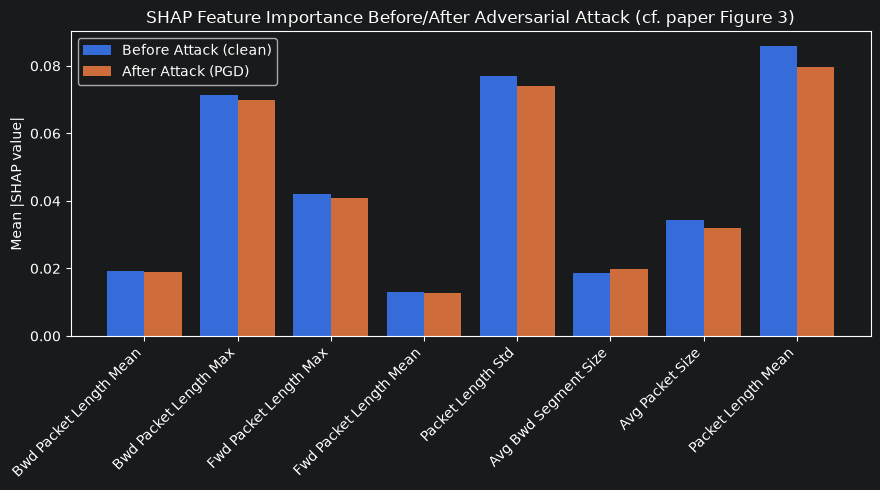

    v [01:23:30.48] Saved shap_feature_importance.png


In [16]:
log.section("Plotting SHAP feature importance (cf. paper Figure 3)")

fig, ax = plt.subplots(figsize=(9, 5))
top8 = stability_series.index[:8]
before_vals = pd.Series(shap_clean_vals, index=selected_features)[top8]
after_vals = pd.Series(shap_adv_vals, index=selected_features)[top8]

x = np.arange(len(top8))
ax.bar(x - 0.2, before_vals, width=0.4, label="Before Attack (clean)")
ax.bar(x + 0.2, after_vals, width=0.4, label="After Attack (PGD)")
ax.set_xticks(x)
ax.set_xticklabels(top8, rotation=45, ha="right")
ax.set_ylabel("Mean |SHAP value|")
ax.set_title("SHAP Feature Importance Before/After Adversarial Attack (cf. paper Figure 3)")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "shap_feature_importance.png"), dpi=150)
plt.show()
log.ok("Saved shap_feature_importance.png")


## Section 16 — Defended model: adversarial training + SHAP-robust features (paper Table 1)

Retrains on the SHAP-selected robust feature subset (stage 1, clean data only), then augments
training data with FGSM/PGD/DeepFool adversarial examples (generated on CPU via ART) and continues
training (stage 2, on GPU). Timing is captured separately for each phase so overhead can be reported
both ways: pure retraining cost vs. total defense-pipeline cost including adversarial example generation.

In [17]:
log.section("Training defended model - stage 1 (clean, robust features)")

feat_idx = [selected_features.index(f) for f in robust_features]
X_train_def = X_train_bal[:, feat_idx]
X_test_def = X_test[:, feat_idx]
X_atk_def = X_atk[:, feat_idx]

defended_model = IDSNet(len(robust_features))
log.info(f"Defended model input_dim={len(robust_features)} (SHAP-robust subset), device={DEVICE}")

t_stage1_start = time.time()
hist_def_stage1 = train_model(
    defended_model, X_train_def, y_train_bal,
    epochs=CONFIG["epochs_defended_stage1"], batch_size=CONFIG["batch_size"],
    device=DEVICE, desc="Defended stage 1 (clean)",
)
t_stage1_time = time.time() - t_stage1_start
log.ok(f"Stage 1 complete in {t_stage1_time/60:.2f} min")

torch.save(defended_model.state_dict(), f"{OUTPUT_DIR}/checkpoints/stage1_seed{CONFIG['seed']}.pt")
log.ok(f"Saved Stage 1 checkpoint for seed {CONFIG['seed']}")



>>> [01:23:30.51] SECTION 14: Training defended model - stage 1 (clean, robust features)
    . [01:23:31.08] Defended model input_dim=15 (SHAP-robust subset), device=cuda


Defended stage 1 (clean): 100%|██████████| 50/50 [1:10:19<00:00, 84.38s/it, loss=0.1614, val_acc=0.9461]

    v [02:33:52.47] Stage 1 complete in 70.36 min
    v [02:33:52.47] Saved Stage 1 checkpoint for seed 42


In [18]:
log.section("Generating adversarial training examples (CPU via ART)")

clip_values_def = (float(X_train_def.min()), float(X_train_def.max()))
classifier_def, _ = make_art_classifier(defended_model, len(robust_features), clip_values_def)
attacks_def = make_attacks(classifier_def)

N_GEN = min(CONFIG["n_adv_train_samples"], len(X_train_def))
gen_idx = np.random.choice(len(X_train_def), N_GEN, replace=False)
X_gen, y_gen = X_train_def[gen_idx], y_train_bal[gen_idx]
log.info(f"Generating adversarial training data from {N_GEN} samples per attack type")

t_gen_start = time.time()
adv_train_X, adv_train_y = [], []
for name, atk in tqdm(list(attacks_def.items()), desc="Generating adv. training data"):
    t0 = time.time()
    # FIX: target ground truth, consistent with cells 26/37, so adversarial training
    # data is a genuine ground-truth-targeted perturbation, not model-prediction-targeted.
    X_adv_gen = atk.generate(x=X_gen, y=to_onehot(y_gen))
    X_adv_gen = apply_feature_mask(X_adv_gen, X_gen, mutable_mask_def)  # ADD THIS LINE
    if name == "DeepFool":
        # BUG FIX: same unbounded-DeepFool issue as cell 26 -- without capping,
        # this floods stage-2 training with samples pinned near clip_values
        # bounds (unrealistic feature vectors), which is what was corrupting
        # the defended model's CLEAN accuracy, not just its attacked accuracy.
        X_adv_gen = cap_to_eps(X_adv_gen, X_gen, EPS, clip_values_def)
    log.ok(f"{name}: {len(X_adv_gen)} adversarial training examples in {time.time()-t0:.1f}s")
    adv_train_X.append(X_adv_gen)
    adv_train_y.append(y_gen)
t_gen_time = time.time() - t_gen_start

X_adv_train = np.vstack(adv_train_X).astype(np.float32)
y_adv_train = np.concatenate(adv_train_y)
X_train_final = np.vstack([X_train_def, X_adv_train]).astype(np.float32)
y_train_final = np.concatenate([y_train_bal, y_adv_train])
log.ok(f"Combined clean+adversarial training set: {X_train_final.shape} | balance: {np.bincount(y_train_final)}")


>>> [02:33:52.55] SECTION 15: Generating adversarial training examples (CPU via ART)
    . [02:33:52.91] Generating adversarial training data from 5000 samples per attack type


Generating adv. training data:  33%|███▎      | 1/3 [00:00<00:00,  3.12it/s]

    v [02:33:53.24] FGSM: 5000 adversarial training examples in 0.3s



Generating adv. training data:  67%|██████▋   | 2/3 [00:07<00:04,  4.15s/it]

    v [02:34:00.06] PGD: 5000 adversarial training examples in 6.8s



Generating adv. training data: 100%|██████████| 3/3 [00:32<00:00, 10.85s/it]


    v [02:34:25.46] DeepFool: 5000 adversarial training examples in 25.4s
    v [02:34:25.71] Combined clean+adversarial training set: (7631036, 15) | balance: [3815650 3815386]


In [19]:
log.section("Training defended model - stage 2 (clean + adversarial)")

# Class-weighted loss to guard against the model collapsing to a single-class predictor
# under heavy adversarial perturbation (observed in earlier runs as F1=0 under strong attacks).
class_weights = compute_class_weight("balanced", classes=np.unique(y_train_final), y=y_train_final)
log.info(f"Class weights: {dict(enumerate(class_weights))}")

t_stage2_start = time.time()
hist_def_stage2 = train_model(
    defended_model, X_train_final, y_train_final,
    epochs=CONFIG["epochs_defended_stage2"], batch_size=CONFIG["batch_size"],
    device=DEVICE, class_weights=class_weights, desc="Defended stage 2 (clean+adv)",
)
t_stage2_time = time.time() - t_stage2_start
log.ok(f"Stage 2 complete in {t_stage2_time/60:.2f} min")

# --- Overhead bookkeeping: pure retraining vs. total pipeline (incl. adversarial generation) ---
defended_train_time_total = t_stage1_time + t_gen_time + t_stage2_time
defended_train_time_fit_only = t_stage1_time + t_stage2_time

pure_retrain_overhead_pct = (defended_train_time_fit_only - baseline_train_time) / baseline_train_time * 100
total_pipeline_overhead_pct = (defended_train_time_total - baseline_train_time) / baseline_train_time * 100

log.metric("Baseline training time", f"{baseline_train_time/60:.2f} min")
log.metric("Defended: stage1 + stage2 (fit only)", f"{defended_train_time_fit_only/60:.2f} min")
log.metric("Defended: + adversarial generation", f"{t_gen_time/60:.2f} min")
log.metric("Defended: total pipeline time", f"{defended_train_time_total/60:.2f} min")
log.metric("Overhead (retraining only)", f"{pure_retrain_overhead_pct:.1f}%")
log.metric("Overhead (full pipeline incl. attack generation)", f"{total_pipeline_overhead_pct:.1f}%")

defended_train_time = defended_train_time_total
overhead_pct = total_pipeline_overhead_pct



>>> [02:34:25.78] SECTION 16: Training defended model - stage 2 (clean + adversarial)
    . [02:34:26.11] Class weights: {0: np.float64(0.9999654056320679), 1: np.float64(1.0000345967616382)}


Defended stage 2 (clean+adv): 100%|██████████| 15/15 [20:58<00:00, 83.89s/it, loss=0.1620, val_acc=0.9463]

    v [02:55:25.99] Stage 2 complete in 21.00 min
    > [02:55:25.99] Baseline training time                     66.27 min
    > [02:55:25.99] Defended: stage1 + stage2 (fit only)       91.35 min
    > [02:55:25.99] Defended: + adversarial generation         0.54 min
    > [02:55:25.99] Defended: total pipeline time              91.90 min
    > [02:55:25.99] Overhead (retraining only)                 37.8%
    > [02:55:25.99] Overhead (full pipeline incl. attack generation) 38.7%


## Section 17 — Re-evaluate defended model against all attacks

In [20]:
log.section("Evaluating defended model")

defended_clean_metrics = evaluate(defended_model, X_test_def, y_test, DEVICE, "Defended (clean)")

classifier_def2, _ = make_art_classifier(
    defended_model, len(robust_features),
    (float(X_test_def.min()), float(X_test_def.max()))
)
attacks_def2 = make_attacks(classifier_def2)

clip_values_def2 = (float(X_test_def.min()), float(X_test_def.max()))

adv_results_after = {}
for name, atk in tqdm(list(attacks_def2.items()), desc="Attacks vs. defended model (CPU)"):
    # FIX: target ground truth (y_atk), not the defended model's own prediction.
    # This is what was causing recall to jump to ~100% under attack -- the untargeted
    # attack was "helpfully" pushing already-misclassified rows back toward correct.
    X_adv2 = atk.generate(x=X_atk_def, y=to_onehot(y_atk))
    X_adv2 = apply_feature_mask(X_adv2, X_atk_def, mutable_mask_def)
    if name == "DeepFool":
        # BUG FIX: same eps-capping as cells 26/34, applied consistently here too.
        X_adv2 = cap_to_eps(X_adv2, X_atk_def, EPS, clip_values_def2)
    adv_results_after[name] = evaluate(defended_model, X_adv2, y_atk, DEVICE, f"Defended under {name}")

    # RECHECK ADDITION: same attack diagnostics as the baseline (Cell 26), so
    # Table 4 can compare success rate / perturbation magnitude before vs. after defense.
    diag = attack_diagnostics(defended_model, X_atk_def, X_adv2, y_atk, DEVICE)
    adv_results_after[name].update(diag)
    log.metric(f"{name} attack success rate (defended)", f"{diag['success_rate']*100:.1f}%  "
               f"(of {diag['n_originally_correct']} originally-correct samples)")

# Square Attack: tabular reimplementation (ART's SquareAttack is image-only), GPU forward passes
X_sq_def = X_sq[:, feat_idx]
X_adv_square2, square_success_after = tabular_square_attack(defended_model, X_sq_def, y_sq, DEVICE, desc="Square Attack (defended)")
square_after = evaluate(defended_model, X_adv_square2, y_sq, DEVICE, "Defended under Square Attack")
square_after["success_rate"] = square_success_after
log.metric("Square Attack success rate (defended)", f"{square_success_after*100:.1f}%")



>>> [02:55:26.12] SECTION 17: Evaluating defended model
    > [02:55:26.99] Defended (clean)                           Acc=0.961  F1=0.912  Prec=0.904  Rec=0.920  Infer=0.0004 ms/sample


Attacks vs. defended model (CPU):  33%|███▎      | 1/3 [00:00<00:00,  6.48it/s]

    > [02:55:27.16] Defended under FGSM                        Acc=0.878  F1=0.633  Prec=0.871  Rec=0.496  Infer=0.0005 ms/sample
    > [02:55:27.17] FGSM attack success rate (defended)        11.5%  (of 1920 originally-correct samples)



Attacks vs. defended model (CPU):  67%|██████▋   | 2/3 [00:03<00:01,  1.83s/it]

    > [02:55:30.16] Defended under PGD                         Acc=0.729  F1=0.238  Prec=0.293  Rec=0.201  Infer=0.0010 ms/sample
    > [02:55:30.16] PGD attack success rate (defended)         24.1%  (of 1920 originally-correct samples)



Attacks vs. defended model (CPU): 100%|██████████| 3/3 [02:31<00:00, 50.37s/it]


    > [02:57:58.13] Defended under DeepFool                    Acc=0.888  F1=0.650  Prec=0.959  Rec=0.492  Infer=0.0010 ms/sample
    > [02:57:58.13] DeepFool attack success rate (defended)    10.3%  (of 1920 originally-correct samples)


Square Attack (defended): 100%|██████████| 300/300 [00:09<00:00, 32.16it/s, still_fooled_target=762, total=1000]

    > [02:58:07.47] Defended under Square Attack               Acc=0.762  F1=0.405  Prec=0.413  Rec=0.397  Infer=0.0015 ms/sample
    > [02:58:07.47] Square Attack success rate (defended)      20.3%


## Section 18 — Summary tables and plots (cf. paper Tables 4-6, Figures 1-2)

**Table 4 now reports all four paper metrics (Accuracy, F1, Precision, Recall)** — the original v2
notebook only showed Accuracy/F1 in the table, even though `evaluate()` computed all four. That's fixed here.

In [21]:
log.section("Building summary tables")

def row(name, m, is_clean=False):
    sr = "-" if is_clean else f"{m.get('success_rate', float('nan'))*100:.2f}"
    return (name, round(m["accuracy"] * 100, 2), round(m["f1"] * 100, 2),
            round(m["precision"] * 100, 2), round(m["recall"] * 100, 2), sr)

rows = [row("Baseline IDS (clean)", baseline_clean_metrics, is_clean=True)]
for name in ["FGSM", "PGD", "DeepFool"]:
    rows.append(row(f"{name} Attack (baseline)", adv_results_before[name]))
rows.append(row("Defended (clean)", defended_clean_metrics, is_clean=True))
for name in ["FGSM", "PGD", "DeepFool"]:
    rows.append(row(f"{name} Attack (defended)", adv_results_after[name]))

table4 = pd.DataFrame(rows, columns=["Model / Condition", "Accuracy (%)", "F1-score (%)",
                                       "Precision (%)", "Recall (%)", "Attack Success Rate (%)"])
print("Table 4 analogue - Accuracy, F1, Precision, Recall, and corrected Attack Success Rate:")
display(table4)

# FIX: Attack Success Rate here now comes from the tabular_square_attack loop's own
# bookkeeping (fraction of originally-correct predictions flipped) rather than the
# `1 - accuracy` proxy used previously, which conflated attack effectiveness with
# pre-existing baseline/defended model errors.
table5 = pd.DataFrame([
    ("Baseline", square_before["accuracy"] * 100, square_before["f1"] * 100,
     square_before["precision"] * 100, square_before["recall"] * 100,
     square_before["success_rate"] * 100),
    ("Defended", square_after["accuracy"] * 100, square_after["f1"] * 100,
     square_after["precision"] * 100, square_after["recall"] * 100,
     square_after["success_rate"] * 100),
], columns=["Model", "Accuracy (%)", "F1-score (%)", "Precision (%)", "Recall (%)",
            "Attack Success Rate (%)"]).round(2)
print("\nTable 5 analogue - black-box Square Attack:")
display(table5)

table6 = pd.DataFrame([
    ("Baseline", baseline_train_time / 3600, baseline_clean_metrics["infer_ms"], "-", "-"),
    ("Defended", defended_train_time_total / 3600, defended_clean_metrics["infer_ms"],
     f"{pure_retrain_overhead_pct:.1f}%", f"{total_pipeline_overhead_pct:.1f}%"),
], columns=["Model", "Training Time (hrs)", "Inference Time (ms/sample)",
            "Overhead (retrain only)", "Overhead (full pipeline)"])
print("\nTable 6 analogue - computational overhead:")
display(table6)



>>> [02:58:07.55] SECTION 18: Building summary tables
Table 4 analogue - Accuracy, F1, Precision, Recall, and corrected Attack Success Rate:


,Model / Condition,Accuracy (%),F1-score (%),Precision (%),Recall (%),Attack Success Rate (%)
0,Baseline IDS (clean),95.40,89.74,87.29,92.34,-
1,FGSM Attack (baseline),74.95,26.00,34.65,20.80,21.56
2,PGD Attack (baseline),68.60,17.59,19.76,15.84,27.87
3,DeepFool Attack (baseline),73.85,32.52,35.80,29.79,24.19
4,Defended (clean),96.14,91.22,90.42,92.04,-
5,FGSM Attack (defended),87.80,63.25,87.14,49.65,11.46
6,PGD Attack (defended),72.85,23.84,29.31,20.09,24.11
7,DeepFool Attack (defended),88.80,65.00,95.85,49.17,10.26



Table 5 analogue - black-box Square Attack:


,Model,Accuracy (%),F1-score (%),Precision (%),Recall (%),Attack Success Rate (%)
0,Baseline,57.6,14.86,12.59,18.14,39.11
1,Defended,76.2,40.50,41.33,39.71,20.29



Table 6 analogue - computational overhead:


,Model,Training Time (hrs),Inference Time (ms/sample),Overhead (retrain only),Overhead (full pipeline)
0,Baseline,1.104516,0.000357,-,-
1,Defended,1.531616,0.000404,37.8%,38.7%



>>> [02:58:08.20] SECTION 19: Epsilon sweep - baseline vs. defended robustness curve


Eps sweep:   0%|          | 0/5 [00:00<?, ?it/s]

    > [02:58:08.40]                                            Acc=0.852  F1=0.625  Prec=0.673  Rec=0.584  Infer=0.0010 ms/sample



PGD - Batches: 100%|██████████| 63/63 [00:02<00:00, 21.86it/s]
                                                              

    > [02:58:11.47]                                            Acc=0.809  F1=0.536  Prec=0.551  Rec=0.522  Infer=0.0010 ms/sample


...

    > [03:10:42.61]                                            Acc=0.620  F1=0.089  Prec=0.090  Rec=0.087  Infer=0.0015 ms/sample
    > [03:10:42.76]                                            Acc=0.810  F1=0.258  Prec=0.742  Rec=0.156  Infer=0.0013 ms/sample



PGD - Batches: 100%|██████████| 63/63 [00:02<00:00, 23.53it/s]
                                                              

    > [03:10:45.67]                                            Acc=0.660  F1=0.093  Prec=0.107  Rec=0.083  Infer=0.0013 ms/sample



Eps sweep: 100%|██████████| 5/5 [15:03<00:00, 180.65s/it]


    > [03:13:11.43]                                            Acc=0.794  F1=0.240  Prec=0.546  Rec=0.154  Infer=0.0013 ms/sample
    v [03:13:11.44] Saved eps_sweep.csv (30 rows)


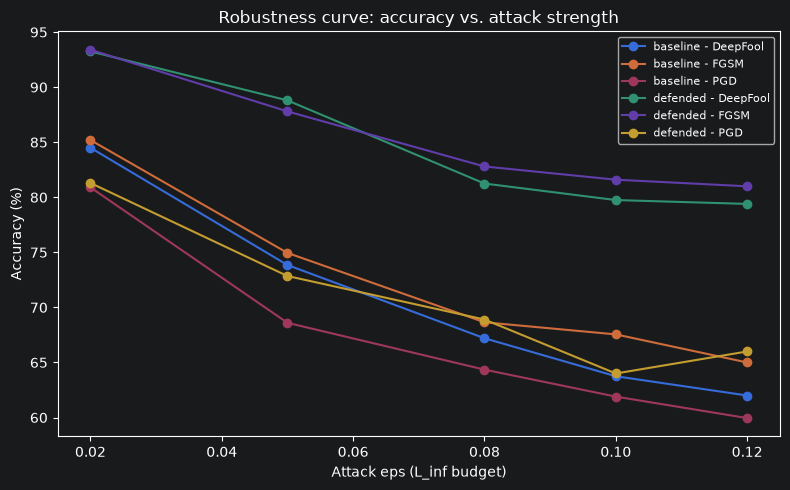

    v [03:13:11.84] Saved eps_sweep_plot.png


In [22]:
log.section("Epsilon sweep - baseline vs. defended robustness curve")

EPS_SWEEP = [0.02, 0.05, 0.08, 0.10, 0.12]
sweep_rows = []

for eps_val in tqdm(EPS_SWEEP, desc="Eps sweep"):
    attacks_sweep = make_attacks(classifier, eps=eps_val)
    attacks_sweep_def = make_attacks(classifier_def2, eps=eps_val)

    for name, atk in attacks_sweep.items():
        X_adv_s = atk.generate(x=X_atk, y=to_onehot(y_atk))
        X_adv_s = apply_feature_mask(X_adv_s, X_atk, mutable_mask)
        if name == "DeepFool":
            X_adv_s = cap_to_eps(X_adv_s, X_atk, eps_val, clip_values)
        m = evaluate(baseline_model, X_adv_s, y_atk, DEVICE, label="")
        sweep_rows.append(("baseline", name, eps_val, m["accuracy"]))

    for name, atk in attacks_sweep_def.items():
        X_adv_s = atk.generate(x=X_atk_def, y=to_onehot(y_atk))
        X_adv_s = apply_feature_mask(X_adv_s, X_atk_def, mutable_mask_def)
        if name == "DeepFool":
            X_adv_s = cap_to_eps(X_adv_s, X_atk_def, eps_val, clip_values_def2)
        m = evaluate(defended_model, X_adv_s, y_atk, DEVICE, label="")
        sweep_rows.append(("defended", name, eps_val, m["accuracy"]))

eps_sweep_df = pd.DataFrame(sweep_rows, columns=["model", "attack", "eps", "accuracy"])
eps_sweep_df.to_csv(f"{OUTPUT_DIR}/eps_sweep.csv", index=False)
log.ok(f"Saved eps_sweep.csv ({len(eps_sweep_df)} rows)")

fig, ax = plt.subplots(figsize=(8, 5))
for (model, attack), grp in eps_sweep_df.groupby(["model", "attack"]):
    grp = grp.sort_values("eps")
    ax.plot(grp["eps"], grp["accuracy"] * 100, marker="o", label=f"{model} - {attack}")
ax.set_xlabel("Attack eps (L_inf budget)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Robustness curve: accuracy vs. attack strength")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/eps_sweep_plot.png", dpi=150)
plt.show()
log.ok("Saved eps_sweep_plot.png")


>>> [03:13:11.93] SECTION 20: Rendering comparison plots


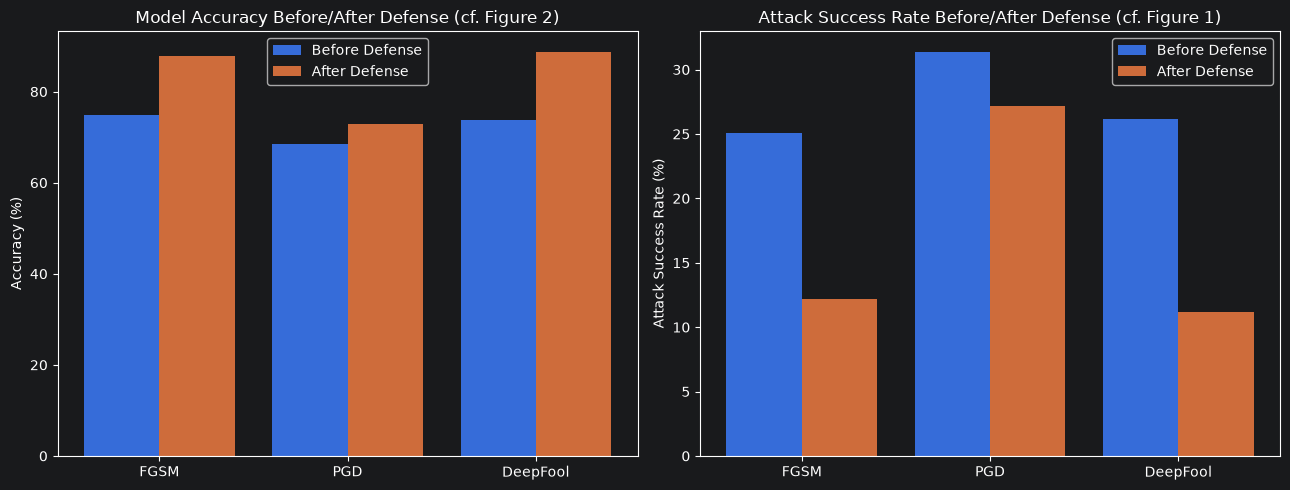

    v [03:13:12.36] Saved comparison_plots.png


In [23]:
log.section("Rendering comparison plots")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

attack_names = ["FGSM", "PGD", "DeepFool"]
before_acc = [adv_results_before[a]["accuracy"] * 100 for a in attack_names]
after_acc = [adv_results_after[a]["accuracy"] * 100 for a in attack_names]

x = np.arange(len(attack_names))
axes[0].bar(x - 0.2, before_acc, width=0.4, label="Before Defense")
axes[0].bar(x + 0.2, after_acc, width=0.4, label="After Defense")
axes[0].set_xticks(x); axes[0].set_xticklabels(attack_names)
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_title("Model Accuracy Before/After Defense (cf. Figure 2)")
axes[0].legend()

success_before = [100 - a for a in before_acc]
success_after = [100 - a for a in after_acc]
axes[1].bar(x - 0.2, success_before, width=0.4, label="Before Defense")
axes[1].bar(x + 0.2, success_after, width=0.4, label="After Defense")
axes[1].set_xticks(x); axes[1].set_xticklabels(attack_names)
axes[1].set_ylabel("Attack Success Rate (%)")
axes[1].set_title("Attack Success Rate Before/After Defense (cf. Figure 1)")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_plots.png"), dpi=150)
plt.show()
log.ok("Saved comparison_plots.png")


## Section 19 — Save all artifacts to the output folder

In [24]:
log.section("Saving all results, models, and artifacts")

SAVE_DIR = OUTPUT_DIR
os.makedirs(SAVE_DIR, exist_ok=True)

table4.to_csv(f"{SAVE_DIR}/table4_accuracy_f1_precision_recall.csv", index=False)
table5.to_csv(f"{SAVE_DIR}/table5_square_attack.csv", index=False)
table6.to_csv(f"{SAVE_DIR}/table6_overhead.csv", index=False)
log.ok("Saved tables 4-6 as CSV")

all_metrics = {
    "baseline_clean": baseline_clean_metrics,
    "baseline_under_attack": adv_results_before,
    "baseline_under_square": square_before,
    "defended_clean": defended_clean_metrics,
    "defended_under_attack": adv_results_after,
    "defended_under_square": square_after,
}
with open(f"{SAVE_DIR}/all_metrics.json", "w") as f:
    json.dump(all_metrics, f, indent=2, default=float)
log.ok("Saved all_metrics.json")

torch.save(baseline_model.state_dict(), f"{SAVE_DIR}/baseline_model.pt")
torch.save(defended_model.state_dict(), f"{SAVE_DIR}/defended_model.pt")
log.ok("Saved baseline_model.pt and defended_model.pt (state_dicts; re-load with IDSNet(...).load_state_dict(...))")

with open(f"{SAVE_DIR}/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
log.ok("Saved scaler.pkl")

mi_scores.to_csv(f"{SAVE_DIR}/mutual_info_scores.csv", header=["mi_score"])
stability_series.to_csv(f"{SAVE_DIR}/shap_stability_scores.csv", header=["stability_score"])
with open(f"{SAVE_DIR}/selected_features.json", "w") as f:
    json.dump({
        "mutual_info_selected": selected_features,
        "shap_robust_selected": robust_features,
        "feature_indices_used_by_defended_model": feat_idx,
    }, f, indent=2)
log.ok("Saved feature selection artifacts")

np.savez(f"{SAVE_DIR}/shap_values.npz",
         shap_clean_values=shap_clean.values, shap_adv_values=shap_adv.values,
         shap_clean_data=X_clean_shap, shap_adv_data=X_adv_shap)
log.ok("Saved shap_values.npz")

np.savez(f"{SAVE_DIR}/adversarial_examples_baseline.npz",
         X_clean=X_atk, y_clean=y_atk,
         X_fgsm=X_adv_store["FGSM"], X_pgd=X_adv_store["PGD"], X_deepfool=X_adv_store["DeepFool"],
         X_square=X_adv_square, y_square=y_sq)
log.ok("Saved adversarial_examples_baseline.npz")

np.savez(f"{SAVE_DIR}/training_history.npz",
         baseline=history, defended_stage1=hist_def_stage1, defended_stage2=hist_def_stage2)
log.ok("Saved training_history.npz")

config_snapshot = dict(CONFIG)
config_snapshot.update({
    "seed": SEED,
    "device": str(DEVICE),
    "n_attack_samples_used": N_ATTACK_SAMPLES,
    "n_square_samples_used": N_SQUARE,
    "n_shap_samples_used": N_SHAP,
    "n_adv_train_samples_used": N_GEN,
    "baseline_train_time_sec": baseline_train_time,
    "defended_stage1_time_sec": t_stage1_time,
    "defended_gen_time_sec": t_gen_time,
    "defended_stage2_time_sec": t_stage2_time,
    "defended_total_time_sec": defended_train_time_total,
    "overhead_retrain_only_pct": pure_retrain_overhead_pct,
    "overhead_full_pipeline_pct": total_pipeline_overhead_pct,
})
with open(f"{SAVE_DIR}/run_config.json", "w") as f:
    json.dump(config_snapshot, f, indent=2, default=str)
log.ok("Saved run_config.json")

for fname in ["shap_feature_importance.png", "comparison_plots.png"]:
    src = os.path.join(OUTPUT_DIR, fname)
    if not os.path.exists(os.path.join(SAVE_DIR, fname)) and os.path.exists(src):
        pass  # already saved directly into SAVE_DIR (== OUTPUT_DIR)

shutil.make_archive(os.path.join(os.path.dirname(SAVE_DIR.rstrip("/")) or ".", "all_results"), "zip", SAVE_DIR)
log.ok(f"Zipped everything to {os.path.join(os.path.dirname(SAVE_DIR.rstrip('/')) or '.', 'all_results.zip')}")

log.section("RUN COMPLETE")
log.metric("Total wall-clock time", log._elapsed())
log.info(f"Files in {SAVE_DIR}/:")
for f in sorted(os.listdir(SAVE_DIR)):
    print(f"        - {f}")



>>> [03:13:12.38] SECTION 21: Saving all results, models, and artifacts
    v [03:13:12.41] Saved tables 4-6 as CSV
    v [03:13:12.41] Saved all_metrics.json
    v [03:13:12.42] Saved baseline_model.pt and defended_model.pt (state_dicts; re-load with IDSNet(...).load_state_dict(...))
    v [03:13:12.43] Saved scaler.pkl
    v [03:13:12.43] Saved feature selection artifacts
    v [03:13:12.43] Saved shap_values.npz
    v [03:13:12.43] Saved adversarial_examples_baseline.npz
    v [03:13:12.43] Saved training_history.npz
    v [03:13:12.43] Saved run_config.json
    v [03:13:12.62] Zipped everything to ./output\all_results.zip

>>> [03:13:12.62] SECTION 22: RUN COMPLETE
    > [03:13:12.62] Total wall-clock time                      03:13:12.62
    . [03:13:12.62] Files in ./output/seed_42/:
        - adversarial_examples_baseline.npz
        - all_metrics.json
        - baseline_model.pt
        - checkpoints
        - comparison_plots.png
        - defended_model.pt
        - eps_swee

## Notes on fidelity to the paper

- **What matches:** the full pipeline (clean -> attack -> measure degradation -> dual-layer defense
  -> re-measure), all four attack types, the SHAP-based feature-stability selection algorithm
  (Table 3), and both an overhead-only and full-pipeline overhead number (Table 6). Table 4 now
  reports all four of the paper's metrics (Accuracy, F1, Precision, Recall) plus a corrected
  Attack Success Rate, not just Accuracy/F1.
- **What can't match exactly:** the paper's specific accuracy figures — it never publishes layer
  sizes, attack epsilons/iterations, feature-selection thresholds, SMOTE settings, or which daily
  files were used, so an exact numeric reproduction isn't achievable, only a faithful
  reimplementation of the same method. Every one of these choices is now exposed in `CONFIG`
  (Section 2) rather than hardcoded, so they can be tuned/reported explicitly as assumptions.
- **PyTorch vs. TensorFlow:** this is a from-scratch PyTorch port of the original TensorFlow/Keras
  reimplementation (same nominal architecture: 128-64-32 MLP, BatchNorm, Dropout(0.3), Adam
  lr=0.001, all now configurable), so absolute numbers will differ slightly (different init,
  optimizer internals, BN implementation) even with the same seed — expect the same *qualitative*
  pattern (large accuracy drop under attack, recovered by defense).
- **GPU backend note — open finding, not yet resolved:** this notebook now targets ROCm
  (`cuda` device, RX7600) instead of DirectML. An earlier ROCm run of this exact
  architecture/config — with the data-loading/cleaning/feature-selection code verified
  byte-identical against a DirectML reference run — produced baseline clean accuracy roughly
  10 points higher (~95-97%) than the DirectML run (~86%, which closely matched the paper's
  85%). Since the only code differences were the backend itself and the `SEED` value, this is
  most likely a genuine backend-level numerical/training-dynamics difference (weight-init RNG
  consumption order, BatchNorm/kernel implementation differences between DirectML and ROCm) —
  **not something this patch silently fixes.** Re-run this notebook and directly compare
  `all_metrics.json` against your DirectML reference run before treating either backend's
  absolute numbers as final; if the gap persists, it's worth reporting as a limitation
  (results are backend-sensitive) rather than picking whichever backend's numbers look better.
- **Seed isolation:** `DATA_SEED` (fixed) controls train/test split, SMOTE, and feature
  selection; `SEED` (varies per run) controls only weight initialization and training
  stochasticity. This lets multi-seed comparisons isolate "is the training recipe stable across
  different initializations" from "are we accidentally training on different data" — the latter
  was a real confound in earlier versions of this notebook, since both used to be tied to a
  single seed value.
- **Attack verification:** every attack (FGSM, PGD, DeepFool, Square) now logs mean L_inf/L2
  perturbation magnitude and a proper success rate (fraction of *originally correct*
  predictions flipped by the attack), confirming attacks are genuinely perturbing inputs and
  giving a metric that isn't conflated with the model's pre-existing clean-data errors.
- **Main tuning levers**, all in `CONFIG` at the top: `attack_eps`/`pgd_eps_step_ratio` (attack
  strength), `day_patterns` (more files -> more data, slower), `top_t_mutual_info`/`top_t_shap`
  (feature counts), `hidden_sizes`/`dropout`/`learning_rate` (architecture), and the epoch
  counts for each training stage.
